# 01 - Exploratory Data Analysis

Sumber: `data/raw/data_labeling.csv` (komentar YouTube berbahasa Indonesia,
label 0 = normal, 1 = promosi judi).

Tujuan tahap ini adalah mengunci empat keputusan yang dipakai seluruh tahap
berikutnya: kunci deduplikasi, `max_length` tokenisasi, kebutuhan class weight,
dan daftar placeholder teks.

Keluaran: figur di `outputs/figures/eda/`.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from src.config import LABEL_COLUMN, RAW_TEXT_COLUMN, settings
from src.models.comment_dataset import load_tokenizer
from src.services.preprocessing import TextCleaner

FIGURE_DIR = settings.output_dir / "figures" / "eda"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 90)

df = pd.read_csv(settings.raw_csv, index_col=0)
print(f"{len(df):,} baris, {len(df.columns)} kolom")
df.head(3)

/workspace/indobert-with-rac/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


14,237 baris, 11 kolom


,number,commentId,author,authorChannelId,textDisplay,textOriginal,likeCount,publishedAt,updatedAt,comment_id,label
0,1,UgwGCePK-opaSTp60494AaABAg.ALZeLIlFw1wALya3HLW348,@andiw_yt,UCy_4eeHHqPad6kIv0Ks2hbw,sudah habis masanya,sudah habis masanya,0,2025-08-18T15:23:53Z,2025-08-18T15:23:53Z,UgwGCePK-opaSTp60494AaABAg.ALZeLIlFw1wALya3HLW348,0
1,2,UgwFbJ1DGuPwCkk_Nbt4AaABAg.ALOQ91rJWfXALaBdWYhLAh,@Midone-w9c,UCtvlX20ymOmALM6PDMH9S4g,Srg hero pool luas coach nya lagi teliti di banding rrq draft sama gitu aja..,Srg hero pool luas coach nya lagi teliti di banding rrq draft sama gitu aja..,0,2025-08-09T04:00:00Z,2025-08-09T04:00:00Z,UgwFbJ1DGuPwCkk_Nbt4AaABAg.ALOQ91rJWfXALaBdWYhLAh,0
2,3,UgxYuOnKVrvEasBZ3mR4AaABAg,@jaajaa7057,UClSjjStQ6RwiRCthd9qYp9w,Gw ingat ayat keramat ini &quot;Di pulangkan oleh tim yg mereka pilih&quot; 😂,"Gw ingat ayat keramat ini ""Di pulangkan oleh tim yg mereka pilih"" 😂",0,2025-08-27T01:55:49Z,2025-08-27T01:55:49Z,UgxYuOnKVrvEasBZ3mR4AaABAg,0


## 1. Struktur kolom dan kelengkapan

In [2]:
info = pd.DataFrame(
    {
        "tipe": df.dtypes.astype(str),
        "kosong": df.isna().sum(),
        "kosong_pct": (df.isna().mean() * 100).round(2),
        "unik": df.nunique(),
    }
)
info

,tipe,kosong,kosong_pct,unik
number,int64,0,0.00,14237
commentId,object,0,0.00,14237
author,object,0,0.00,11321
authorChannelId,object,0,0.00,11320
textDisplay,object,0,0.00,9649
textOriginal,object,10,0.07,9465
likeCount,int64,0,0.00,211
publishedAt,object,0,0.00,12601
updatedAt,object,0,0.00,12597
comment_id,object,0,0.00,14237


Hanya `textOriginal` dan `label` yang dipakai untuk pemodelan. Kolom lain
(`commentId`, `author`, `authorChannelId`, `publishedAt`, dan seterusnya) adalah
metadata; sebagiannya memuat identitas dan tidak ikut ke tahap berikutnya.

## 2. Distribusi label

label
0    8560
1    5677

rasio mayoritas:minoritas = 1.51:1


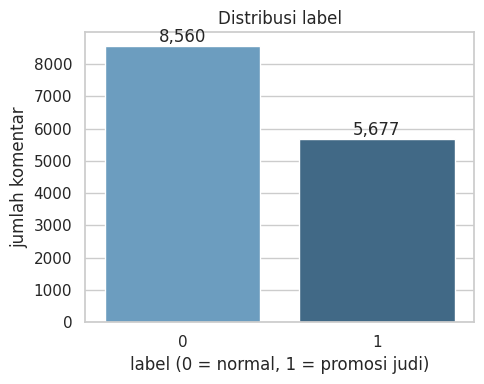

In [3]:
counts = df[LABEL_COLUMN].value_counts().sort_index()
ratio = counts.max() / counts.min()
print(counts.to_string())
print(f"\nrasio mayoritas:minoritas = {ratio:.2f}:1")

fig, ax = plt.subplots(figsize=(5, 4))
sns.barplot(x=counts.index.astype(str), y=counts.to_numpy(), ax=ax,
            hue=counts.index.astype(str), legend=False, palette="Blues_d")
for i, value in enumerate(counts.to_numpy()):
    ax.text(i, value, f"{value:,}", ha="center", va="bottom")
ax.set_xlabel("label (0 = normal, 1 = promosi judi)")
ax.set_ylabel("jumlah komentar")
ax.set_title("Distribusi label")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "label_distribution.png", dpi=120)
plt.show()

Ketimpangan kelas berarti accuracy tidak informatif: menebak semua komentar
sebagai normal sudah memberi akurasi tinggi tanpa mendeteksi satu pun promosi
judi. Metrik utama karena itu F1-macro, dengan F1 kelas 1 sebagai pemecah seri,
dan loss diberi class weight yang dihitung dari split train.

## 3. Duplikasi dan konflik label

In [4]:
cleaner = TextCleaner()
valid = df[df[RAW_TEXT_COLUMN].notna() & df[LABEL_COLUMN].notna()].copy()
valid["nfkc_key"] = valid[RAW_TEXT_COLUMN].map(cleaner.normalize_nfkc)

n_exact = valid[RAW_TEXT_COLUMN].duplicated().sum()
n_nfkc = valid["nfkc_key"].duplicated().sum()
print(f"duplikat exact          : {n_exact:,}")
print(f"duplikat setelah NFKC   : {n_nfkc:,}  (+{n_nfkc - n_exact:,} tertangkap NFKC)")

conflict = valid.groupby("nfkc_key")[LABEL_COLUMN].nunique()
conflict_keys = conflict[conflict > 1].index
print(f"grup dengan label bertentangan: {len(conflict_keys)} "
      f"({valid['nfkc_key'].isin(conflict_keys).sum()} baris)")

duplikat exact          : 4,762
duplikat setelah NFKC   : 4,815  (+53 tertangkap NFKC)
grup dengan label bertentangan: 3 (32 baris)


Selisih antara duplikat exact dan duplikat NFKC adalah komentar yang sengaja
diobfuskasi dengan varian Unicode (fullwidth, double-struck, enclosed) supaya
lolos penyaringan berbasis kecocokan teks. Karena itu kunci deduplikasi yang
dipakai adalah NFKC, bukan teks mentah.

Grup dengan label bertentangan diselesaikan ke label 1: kebijakan konservatif
untuk tugas deteksi.

## 4. Panjang teks dan pemilihan `max_length`

In [5]:
tokenizer = load_tokenizer()
sample = valid[RAW_TEXT_COLUMN].astype(str)

lengths = pd.DataFrame(
    {
        "karakter": sample.str.len(),
        "kata": sample.str.split().str.len(),
        "token": [len(tokenizer.tokenize(text)) for text in sample],
    }
)
lengths.describe(percentiles=[0.5, 0.9, 0.95, 0.99]).round(1)

,karakter,kata,token
count,14227.0,14227.0,14227.0
mean,49.6,7.9,11.2
std,44.3,7.2,10.5
min,1.0,1.0,1.0
50%,43.0,7.0,9.0
90%,88.0,14.0,21.0
95%,115.0,19.0,30.0
99%,240.0,39.0,52.0
max,886.0,160.0,252.0


P99 panjang token          : 52
max_length dipakai         : 128
komentar yang terpotong    : 0.035%


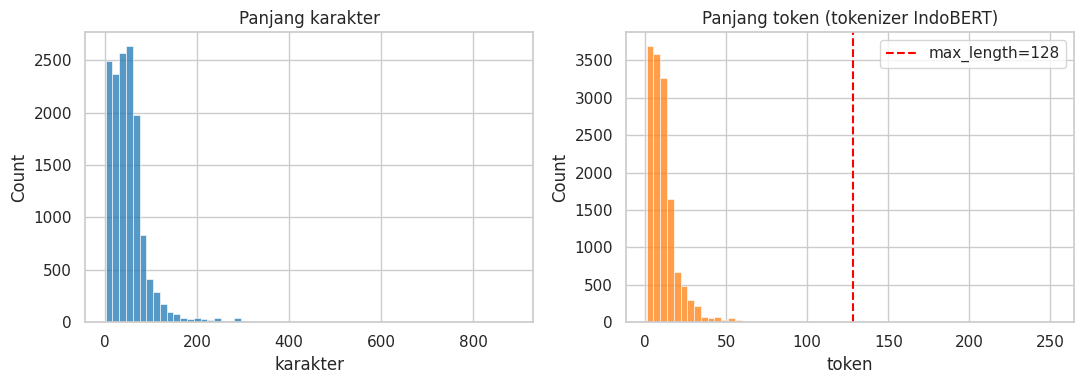

In [6]:
p99 = lengths["token"].quantile(0.99)
truncated = (lengths["token"] > settings.max_length).mean() * 100
print(f"P99 panjang token          : {p99:.0f}")
print(f"max_length dipakai         : {settings.max_length}")
print(f"komentar yang terpotong    : {truncated:.3f}%")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(lengths["karakter"], bins=60, ax=axes[0], color="tab:blue")
axes[0].set_title("Panjang karakter")
axes[0].set_xlabel("karakter")

sns.histplot(lengths["token"], bins=60, ax=axes[1], color="tab:orange")
axes[1].axvline(settings.max_length, color="red", linestyle="--",
                label=f"max_length={settings.max_length}")
axes[1].set_title("Panjang token (tokenizer IndoBERT)")
axes[1].set_xlabel("token")
axes[1].legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / "text_length_histogram.png", dpi=120)
plt.show()

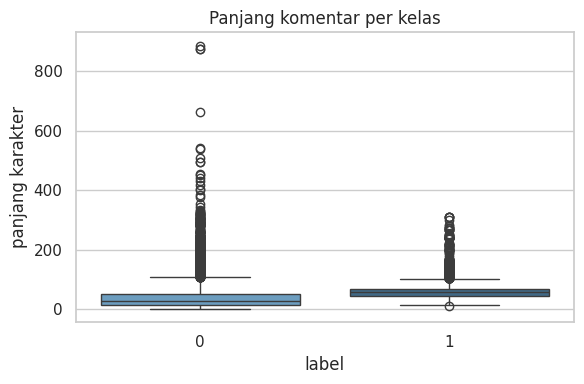

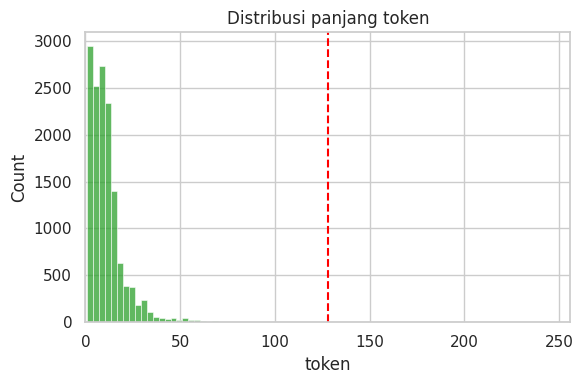

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(data=valid.assign(karakter=lengths["karakter"].to_numpy()),
            x=LABEL_COLUMN, y="karakter", ax=ax,
            hue=LABEL_COLUMN, legend=False, palette="Blues_d")
ax.set_xlabel("label")
ax.set_ylabel("panjang karakter")
ax.set_title("Panjang komentar per kelas")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "text_length_boxplot.png", dpi=120)
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
sns.histplot(lengths["token"], bins=80, ax=ax, color="tab:green")
ax.set_xlim(0, 256)
ax.axvline(settings.max_length, color="red", linestyle="--")
ax.set_xlabel("token")
ax.set_title("Distribusi panjang token")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "token_length_distribution.png", dpi=120)
plt.show()

`max_length` 128 menyisakan margin lebar di atas P99 dengan pemotongan yang
dapat diabaikan. Menaikkannya hanya menambah komputasi tanpa menambah informasi.

## 5. Sebaran waktu

/tmp/ipykernel_2282/1519244531.py:4: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  pd.DataFrame({"bulan": waktu.dt.to_period("M"), LABEL_COLUMN: df[LABEL_COLUMN]})


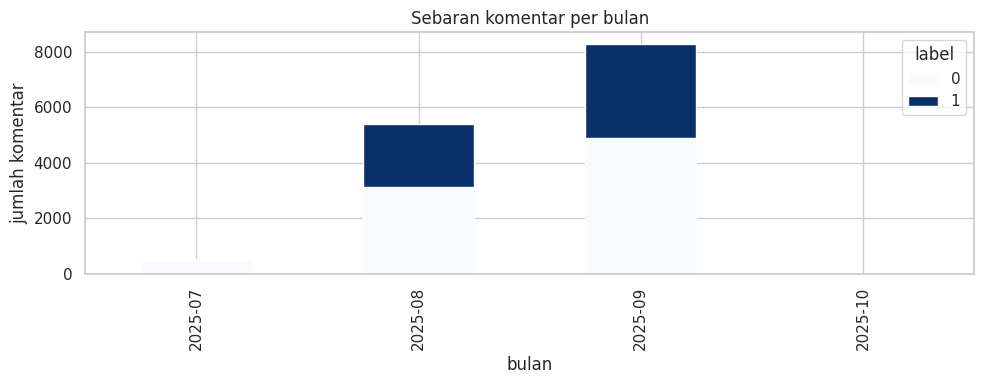

In [8]:
if "publishedAt" in df.columns:
    waktu = pd.to_datetime(df["publishedAt"], utc=True, errors="coerce")
    per_bulan = (
        pd.DataFrame({"bulan": waktu.dt.to_period("M"), LABEL_COLUMN: df[LABEL_COLUMN]})
        .dropna()
        .groupby(["bulan", LABEL_COLUMN])
        .size()
        .unstack(fill_value=0)
    )
    fig, ax = plt.subplots(figsize=(10, 4))
    per_bulan.plot(kind="bar", stacked=True, ax=ax, colormap="Blues")
    ax.set_xlabel("bulan")
    ax.set_ylabel("jumlah komentar")
    ax.set_title("Sebaran komentar per bulan")
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / "temporal_distribution.png", dpi=120)
    plt.show()

## 6. Pola teks kelas judi

In [9]:
judi = valid[valid[LABEL_COLUMN] == 1][RAW_TEXT_COLUMN].astype(str)
normal = valid[valid[LABEL_COLUMN] == 0][RAW_TEXT_COLUMN].astype(str)

pola = {
    "mengandung URL": r"https?://|www\.|t\.me/",
    "mengandung mention": r"@\w+",
    "mengandung angka": r"\b\d+\b",
    "mengandung emoji": r"[\U0001F300-\U0001FAFF]",
}
ringkas = pd.DataFrame(
    {
        "judi_pct": {k: judi.str.contains(v, regex=True).mean() * 100 for k, v in pola.items()},
        "normal_pct": {k: normal.str.contains(v, regex=True).mean() * 100 for k, v in pola.items()},
    }
).round(2)
ringkas

,judi_pct,normal_pct
mengandung URL,0.00,0.23
mengandung mention,0.00,3.77
mengandung angka,30.83,7.40
mengandung emoji,31.57,36.36


URL, mention, dan angka jauh lebih sering muncul di kelas judi. Ketiganya
diganti placeholder `[URL]`, `[MENTION]`, dan `[NUM]` saat preprocessing supaya
model belajar polanya, bukan menghafal alamat atau nominal tertentu.

Angka hanya diganti bila berdiri sendiri: nama situs seperti DORA77 justru
sinyal kuat dan harus dipertahankan utuh.

In [10]:
print("=== contoh kelas 1 (promosi judi) ===")
for text in judi.sample(5, random_state=settings.random_seed):
    print(f"  RAW  : {text[:100]}")
    print(f"  CLEAN: {cleaner.clean(text)[:100]}\n")

print("=== contoh kelas 0 (normal) ===")
for text in normal.sample(3, random_state=settings.random_seed):
    print(f"  RAW  : {text[:100]}")
    print(f"  CLEAN: {cleaner.clean(text)[:100]}\n")

=== contoh kelas 1 (promosi judi) ===
  RAW  : Terpopuler Ｇ ＡＲ ＵＤ Ａ Ｈ ０ Ｋ ｌ Spesial Kemerdekaan Berbagi Kemenangan
  CLEAN: Terpopuler G AR UD A H [NUM] K l Spesial Kemerdekaan Berbagi Kemenangan

  RAW  : Teman yang jarang update pun pasang story tentang 🄿🅄🄻🄰🅄🅆🄸🄽.
  CLEAN: Teman yang jarang update pun pasang story tentang PULAUWIN.

  RAW  : Sumpah 5-8 angka kesukaan ku pisan, 🤎𝐏𝐑𝐎𝐁𝐄𝐓 𝟖𝟓𝟓🤎
  CLEAN: Sumpah [NUM]-[NUM] angka kesukaan ku pisan, 🤎PROBET [NUM]🤎

  RAW  : Temen gue ngedm, “Pᴜʟᴀᴜᴡɪɴ itu makanan kek, atau apa sih bro?”
  CLEAN: Temen gue ngedm, “Pᴜʟᴀᴜᴡɪɴ itu makanan kek, atau apa sih bro?”

  RAW  : Pulau777 selalu kasih kejutan 🎁
  CLEAN: Pulau777 selalu kasih kejutan 🎁

=== contoh kelas 0 (normal) ===
  RAW  : Punya jngler bagus masang jngler pokok kaya tlid jg poke jngeler bagus gak di pake😂
  CLEAN: Punya jngler bagus masang jngler pokok kaya tlid jg poke jngeler bagus gak di pake😂

  RAW  : Semua orang tertuju pada perfom rinz yg jelek, gua setuju sih emang jelek. 
Tapi 

## Keputusan yang dikunci untuk tahap berikutnya

| Keputusan | Nilai | Alasan |
|---|---|---|
| Kunci deduplikasi | NFKC-exact | Menangkap obfuskasi varian Unicode |
| Konflik label | Set ke 1 | Konservatif untuk tugas deteksi |
| `max_length` | 128 | Jauh di atas P99, pemotongan dapat diabaikan |
| Class weight | Dihitung dari train | Rasio kelas sekitar 4,5:1 |
| Placeholder | `[URL]`, `[MENTION]`, `[NUM]` | Pola, bukan hafalan nilai spesifik |
| Lowercase manual | Tidak | Tokenizer p2 sudah uncased |
| Emoji dan tanda baca | Dipertahankan | Bagian dari gaya penulisan promosi |

Lanjut ke `02_preprocessing.ipynb`.